# Predicción de Producción de un Parque Eólico - Caso de Estudio ML

**Autor:** Fernando Borbón &nbsp;|&nbsp; **Proyecto:** [Windward](https://windward.forwardforecasting.eu/) (servicio en producción, en vivo)
 &nbsp;|&nbsp; **Parque analizado:** Kelmarsh Wind Farm (dataset SCADA real y abierto, 6 aerogeneradores, 2016)

Este notebook es un caso de estudio autocontenido extraído de **Windward**, un sistema de
predicción de producción eólica y soporte a operaciones desplegado como un servicio real en AWS. Este Notebook reutiliza los módulos reales de producción del proyecto
(`forecasting/`, `analysis/`, `data_sources/`). El objetivo es mostrar exactamente las mismas funciones, definiciones de
variables y decisiones de modelado que corren en producción, junto con el análisis adicional de
exploración, comparación y monitorización que un caso de estudio técnico requiere.

El parque eólico en estudio es Kelmarsh, ubicado en Reino Unido, como se muestra a continuación: 

<img src="Keimarsh_windfarm_layout.png" width="720" alt="Disposición del parque Kelmarsh">

*Disposición (siting) real de los 6 aerogeneradores de Kelmarsh Wind Farm - plano del parque analizado en este notebook.*


## Indice
1. [Definición del Problema](#1)
2. [Fuentes de Datos y Exploración](#2)
3. [Preparación de Datos e Ingeniería de Variables](#3)
4. [Modelado - Baselines vs. Modelos Candidatos](#4)
5. [Resultados y Evaluación](#5)
6. [Eficiencia y Diagnóstico Físico (extra, reutilizando `analysis/efficiency.py`)](#6)
7. [Pipeline, Reproducibilidad y Despliegue en Producción](#7)
8. [Monitorización, Detección de Drift y Estrategia de Reentrenamiento](#8)
9. [Hallazgos y Accionabilidad para el Negocio](#9)
10. [Conclusión](#10)

<a id="1"></a>
## 1. Definición del Problema

### Contexto de negocio
Los operadores de parques eólicos venden electricidad en mercados de energía del día siguiente
("day-ahead") y necesitan una estimación precisa de cuánta energía producirán en las próximas
horas/días para ofertar correctamente, planificar ventanas de mantenimiento, y evitar las
**penalizaciones por desvío** (el coste de entregar de más o de menos respecto a lo ofertado).
Windward resuelve esto para un operador/gestor de activos: dadas las condiciones meteorológicas
y de mercado, predice la producción horaria del parque, y combina esa predicción con una capa de
diagnóstico operacional (detección de anomalías, benchmarking de eficiencia) que convierte los
números en acciones concretas.

### Objetivo
Predecir la **producción horaria agregada de un parque eólico (MW)**, entre 1 y 48h vista, a
partir de variables externas que se pueden pronosticar: meteorología (velocidad/dirección del
viento, temperatura, presión) y precio de la energía del día siguiente - **no** los sensores
propios de los aerogeneradores, ya que esos no están disponibles con antelación para una
predicción real.

### Métricas de éxito

| Tipo | Métrica | Por qué |
|---|---|---|
| Técnica | MAE (MW), RMSE (MW), R² | Calidad de regresión estándar; el MAE es directamente interpretable en las unidades de producción del propio parque |
| Técnica | MAPE (%) | Error relativo, comparable entre parques de distinta capacidad - pero ver la advertencia del §5 |
| Negocio | **Proxy de coste por desvío** (Σ \|error\| × precio day-ahead) | Convierte el error de predicción directamente en exposición en € - el número que realmente le importa a un trader de energía |
| Negocio | Mejora frente a un baseline ingenuo | Un modelo de predicción solo justifica su complejidad si supera claramente "predecir simplemente la media" |

### Alcance de este notebook
Ciclo de vida completo sobre **un parque** (Kelmarsh, 6 aerogeneradores, año completo 2016 de
SCADA real) para ganar profundidad dentro del tiempo disponible; el mismo código corre sin
modificaciones para los otros dos parques registrados (`data_sources/farms.py`) ya que nada aquí
es específico de un parque en particular.

<a id="2"></a>
## 2. Fuentes de Datos y Exploración

**Datos reales, dos fuentes independientes, unidas por tiempo:**
- **Producción (variable objetivo):** exportación SCADA real de Kelmarsh Wind Farm (Cubico
  Sustainable Investments, CC BY 4.0, Zenodo DOI `10.5281/zenodo.5841834`) - datos cada 10
  minutos por aerogenerador, 6 aerogeneradores, remuestreados a horario y sumados a nivel de
  parque en MW.
- **Meteorología (variables predictoras):** histórico real de reanálisis ERA5 vía la API de
  Open-Meteo (gratuita, sin clave), consultado para las coordenadas exactas del parque y el
  período del SCADA.
- **Precio day-ahead:** sintético (una curva realista de día/noche) para este notebook - la fuente
  real de ENTSO-E requiere un token de API personal; el código de producción
  (`data_sources/energy_price_client.py`) cambia de forma transparente a la fuente real en cuanto
  se configura `ENTSOE_API_TOKEN`, con el mismo código posterior en ambos casos.

Toda la carga de datos a continuación llama a las **funciones reales de carga de producción** -
sin reimplementar nada.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "demo_notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 4)

from data_sources.farms import FARMS, loader_for
from analysis.efficiency import binned_power_curve, air_density_kg_m3, AIR_DENSITY_KG_M3, BETZ_LIMIT

FARM_ID = "kelmarsh"
farm = FARMS[FARM_ID]
farm

Farm(farm_id='kelmarsh', name='Kelmarsh Wind Farm', lat=52.400604, lon=-0.947133, bidding_zone_eic='10YGB----------A', turbine_ids=['Kelmarsh_1', 'Kelmarsh_2', 'Kelmarsh_3', 'Kelmarsh_4', 'Kelmarsh_5', 'Kelmarsh_6'], rated_power_kw=2050.0, rotor_diameter_m=92.0, manufacturer_model='Senvion MM92', scada_zips=[PosixPath('/home/patito/Developments/windward/data/kelmarsh/Kelmarsh_SCADA_2016.zip')], source_doi='10.5281/zenodo.5841834', data_source='greenbyte')

In [2]:
# Metadatos estáticos reales por aerogenerador (coordenadas, fabricante, potencia nominal) - del propio dataset
turbine_static = loader_for(farm).load_turbine_static(FARM_ID)
turbine_static[["Manufacturer", "Model", "Rated power (kW)", "Hub Height (m)", "Latitude", "Longitude"]]

,Manufacturer,Model,Rated power (kW),Hub Height (m),Latitude,Longitude
turbine_id,,,,,,
Kelmarsh_1,Senvion,MM92,2050,78.5,52.400604,-0.947133
Kelmarsh_2,Senvion,MM92,2050,78.5,52.402551,-0.949527
Kelmarsh_3,Senvion,MM92,2050,68.5,52.403834,-0.944190
Kelmarsh_4,Senvion,MM92,2050,78.5,52.398781,-0.941150
Kelmarsh_5,Senvion,MM92,2050,78.5,52.402308,-0.940537
Kelmarsh_6,Senvion,MM92,2050,68.5,52.400687,-0.936093


Ejemplo de analysis de calidad de datos

In [3]:
from IPython.display import Markdown, display
import zipfile

RAW_QUALITY_COLUMNS = [
    "Wind speed (m/s)", "Wind direction (°)", "Nacelle position (°)",
    "Power (kW)", "Power factor (cosphi)",
    "Rotor speed (RPM)", "Generator RPM (RPM)", "Gearbox speed (RPM)",
    "Blade angle (pitch position) A (°)",
    "Front bearing temperature (°C)", "Rear bearing temperature (°C)",
    "Nacelle ambient temperature (°C)", "Generator bearing front temperature (°C)",
    "Rotor bearing temp (°C)",
]

def raw_quality_report(raw_df, columns):
    """Auditoría de calidad sobre el CSV crudo (sin parsear a numérico, sin resamplear, sin
    recortar) de UN aerogenerador, para cada variable: % de valores faltantes, % con formato
    incorrecto (texto donde debería haber un número), % de valores extremos compatibles con un
    error de coma decimal o de unidad (vía un z-score robusto basado en la mediana y el MAD -
    ver nota debajo de la tabla), y % de valores "atascados" (el mismo valor repetido 3 o más
    lecturas seguidas - la firma clásica de un sensor congelado)."""
    rows = []
    n = len(raw_df)
    for col in columns:
        raw_col = raw_df[col].astype(str).str.strip()
        is_missing = raw_df[col].isna() | (raw_col == "") | (raw_col.str.lower() == "nan")
        numeric = pd.to_numeric(raw_df[col], errors="coerce")
        is_bad_format = numeric.isna() & ~is_missing

        valid = numeric.dropna()
        n_extreme = 0
        if len(valid) > 10:
            med = valid.median()
            mad = (valid - med).abs().median()
            robust_z = (valid - med).abs() / (1.4826 * mad + 1e-9)
            n_extreme = int((robust_z > 10).sum())

        eq_prev = numeric.eq(numeric.shift(1))
        eq_prev2 = numeric.eq(numeric.shift(2))
        n_stuck = int((eq_prev & eq_prev2 & numeric.notna()).sum())

        rows.append({
            "variable": col,
            "% faltante (NaN)": is_missing.sum() / n,
            "% formato incorrecto": is_bad_format.sum() / n,
            "% posible error decimal/unidad": n_extreme / n,
            "% valores \"atascados\" (≥3 seguidos)": n_stuck / n,
        })
    return pd.DataFrame(rows).set_index("variable")


# Carga deliberadamente CRUDA: directamente del CSV dentro del zip, como texto (dtype=str),
# sin pasar por greenbyte_scada.py - así se pueden detectar problemas de formato que el loader
# de producción, al forzar los tipos, ya habría ocultado.
with zipfile.ZipFile(farm.scada_zips[0]) as zf:
    raw_member = [n for n in zf.namelist() if n.startswith("Turbine_Data_Kelmarsh_1_")][0]
    with zf.open(raw_member) as f:
        raw_turbine_1 = pd.read_csv(f, skiprows=9, header=0, dtype=str)

quality_report = raw_quality_report(raw_turbine_1, RAW_QUALITY_COLUMNS)
display(
    quality_report.style.format("{:.1%}")
    .background_gradient(cmap="Reds", vmin=0, vmax=0.4)
    .set_caption(f"Kelmarsh_1 - {len(raw_turbine_1):,} filas crudas, {len(RAW_QUALITY_COLUMNS)} variables")
)

worst_missing = quality_report["% faltante (NaN)"].idxmax()
worst_stuck_col = "% valores \"atascados\" (≥3 seguidos)"
worst_stuck = quality_report[worst_stuck_col].idxmax()
display(Markdown(f"""
**Lectura de la tabla (hallazgos reales, no simulados):**
- **Formato:** 0% de valores con formato incorrecto en ninguna variable - esta exportación ya
  llega como texto numérico limpio. Si viniera de un histórico más antiguo o de otro proveedor,
  aquí es donde aparecerían cosas como `"1,234"` con coma de miles, `"N/A"` o `"#REF!"` colándose
  en una columna numérica.
- **Valores faltantes:** varían sustancialmente por variable, desde ~{quality_report['% faltante (NaN)'].min():.0%}
  en las señales primarias (velocidad de viento, potencia) hasta ~{quality_report['% faltante (NaN)'].max():.0%}
  en **{worst_missing}** - consistente con que distintos subsistemas del aerogenerador se
  loguean con disponibilidad ligeramente distinta, no con un fallo uniforme de todo el sensor.
- **Posible error decimal/unidad:** el z-score robusto (mediana + MAD) es la herramienta correcta
  para variables con una distribución razonablemente unimodal (temperaturas, potencia, velocidad
  de viento - ahí el % es {quality_report.loc[['Front bearing temperature (°C)', 'Rear bearing temperature (°C)'], '% posible error decimal/unidad'].max():.1%} como mucho, y merecería una revisión puntual, no una alarma masiva).
  Pero **falla como método** en `Power factor (cosphi)` y en `Blade angle (pitch position) A (°)`:
  ambas tienen una distribución genuinamente bimodal (el factor de potencia cambia de signo según
  el sentido de la potencia reactiva; el ángulo de pitch se queda pegado a ~0° casi todo el tiempo
  y salta a valores altos solo durante la regulación en viento fuerte), lo que hace que la mediana
  y el MAD dejen de ser un centro/escala representativos y el z-score marque como "extremo" lo que
  en realidad es comportamiento físico normal. Es un hallazgo metodológico real, no un error de
  los datos: un chequeo de calidad automático necesita conocer la forma esperada de cada señal, no
  aplicarse a ciegas por igual a todas.
- **Valores "atascados":** **{worst_stuck}** es la variable con más repeticiones consecutivas
  ({quality_report.loc[worst_stuck, worst_stuck_col]:.0%} de las lecturas) - de nuevo, no implica
  necesariamente un sensor congelado: la posición de la góndola y el ángulo de pitch son señales
  que genuinamente permanecen constantes mientras no hace falta re-orientar la turbina o regular
  potencia. Distinguir "sensor roto" de "la turbina de verdad no se movió" exige cruzar esta señal
  con el estado operativo real (`status_events`, ya cargado en §2), no solo mirar el porcentaje.
"""))

,% faltante (NaN),% formato incorrecto,% posible error decimal/unidad,"% valores ""atascados"" (≥3 seguidos)"
variable,,,,
Wind speed (m/s),7.5%,0.0%,0.0%,0.0%
Wind direction (°),34.5%,0.0%,0.0%,0.0%
Nacelle position (°),34.5%,0.0%,0.0%,36.9%
Power (kW),7.5%,0.0%,0.0%,0.0%
Power factor (cosphi),7.5%,0.0%,21.5%,15.1%
Rotor speed (RPM),34.6%,0.0%,0.0%,1.1%
Generator RPM (RPM),34.5%,0.0%,0.0%,0.0%
Gearbox speed (RPM),34.5%,0.0%,0.0%,0.6%
Blade angle (pitch position) A (°),34.5%,0.0%,27.5%,29.5%



**Lectura de la tabla (hallazgos reales, no simulados):**
- **Formato:** 0% de valores con formato incorrecto en ninguna variable - esta exportación ya
  llega como texto numérico limpio. Si viniera de un histórico más antiguo o de otro proveedor,
  aquí es donde aparecerían cosas como `"1,234"` con coma de miles, `"N/A"` o `"#REF!"` colándose
  en una columna numérica.
- **Valores faltantes:** varían sustancialmente por variable, desde ~7%
  en las señales primarias (velocidad de viento, potencia) hasta ~35%
  en **Rotor speed (RPM)** - consistente con que distintos subsistemas del aerogenerador se
  loguean con disponibilidad ligeramente distinta, no con un fallo uniforme de todo el sensor.
- **Posible error decimal/unidad:** el z-score robusto (mediana + MAD) es la herramienta correcta
  para variables con una distribución razonablemente unimodal (temperaturas, potencia, velocidad
  de viento - ahí el % es 0.6% como mucho, y merecería una revisión puntual, no una alarma masiva).
  Pero **falla como método** en `Power factor (cosphi)` y en `Blade angle (pitch position) A (°)`:
  ambas tienen una distribución genuinamente bimodal (el factor de potencia cambia de signo según
  el sentido de la potencia reactiva; el ángulo de pitch se queda pegado a ~0° casi todo el tiempo
  y salta a valores altos solo durante la regulación en viento fuerte), lo que hace que la mediana
  y el MAD dejen de ser un centro/escala representativos y el z-score marque como "extremo" lo que
  en realidad es comportamiento físico normal. Es un hallazgo metodológico real, no un error de
  los datos: un chequeo de calidad automático necesita conocer la forma esperada de cada señal, no
  aplicarse a ciegas por igual a todas.
- **Valores "atascados":** **Nacelle position (°)** es la variable con más repeticiones consecutivas
  (37% de las lecturas) - de nuevo, no implica
  necesariamente un sensor congelado: la posición de la góndola y el ángulo de pitch son señales
  que genuinamente permanecen constantes mientras no hace falta re-orientar la turbina o regular
  potencia. Distinguir "sensor roto" de "la turbina de verdad no se movió" exige cruzar esta señal
  con el estado operativo real (`status_events`, ya cargado en §2), no solo mirar el porcentaje.


In [4]:
# Producción horaria real a nivel de parque (SCADA, sumada entre aerogeneradores) - esta es nuestra variable OBJETIVO
farm_production = loader_for(farm).load_farm_hourly_production(farm.scada_zips)

# Velocidad de viento y potencia horaria real por aerogenerador - se usa más adelante para el análisis de eficiencia/curva de potencia
turbine_hourly = loader_for(farm).load_turbine_hourly_series(farm.scada_zips)

# Registro real de eventos de estado/fallo por aerogenerador - se usa más adelante para el corpus RAG y, aquí, para un chequeo de calidad de datos
status_events = loader_for(farm).load_status_events(farm.scada_zips)

print(f"farm_production: {farm_production.shape}, {farm_production.index.min()} -> {farm_production.index.max()}")
print(f"turbine_hourly:   {turbine_hourly.shape} (formato largo, {turbine_hourly['turbine_id'].nunique()} aerogeneradores)")
print(f"status_events:    {status_events.shape}")
farm_production.describe()

farm_production: (8174, 1), 2016-01-21 14:00:00 -> 2016-12-31 23:00:00
turbine_hourly:   (47703, 4) (formato largo, 6 aerogeneradores)
status_events:    (14019, 8)


,output_mw
count,8174.000000
mean,3.007214
std,2.865105
min,0.000000
25%,0.757859
50%,2.079163
75%,4.500229
max,12.268583


In [5]:
# Chequeo básico de calidad de datos antes de nada más: hay huecos / valores no finitos en la variable objetivo?
full_range = pd.date_range(farm_production.index.min(), farm_production.index.max(), freq="1h")
missing_hours = full_range.difference(farm_production.index)
print(f"Horas esperadas en el rango: {len(full_range)}, presentes: {len(farm_production)}, "
      f"faltantes: {len(missing_hours)} ({len(missing_hours)/len(full_range):.1%})")
print(f"Valores no finitos en output_mw: {(~np.isfinite(farm_production['output_mw'])).sum()}")
print(f"Valores negativos (no debería haber ninguno, el loader los recorta a 0): {(farm_production['output_mw'] < 0).sum()}")

Horas esperadas en el rango: 8290, presentes: 8174, faltantes: 116 (1.4%)
Valores no finitos en output_mw: 0
Valores negativos (no debería haber ninguno, el loader los recorta a 0): 0


Hay huecos reales (~7% de las horas) - algo esperable en datos SCADA reales (caídas de sensores,
ventanas de mantenimiento planificado, el archivo simplemente sin los registros de 10 minutos de
esos aerogeneradores). No imputamos: las horas de producción faltantes se descartan más adelante
mediante el `dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN])` de `build_training_frame`
(`forecasting/pipeline.py`), que es la decisión correcta aquí - imputar un proceso físico como la
producción de un aerogenerador arriesga inventar una señal que nunca se observó.

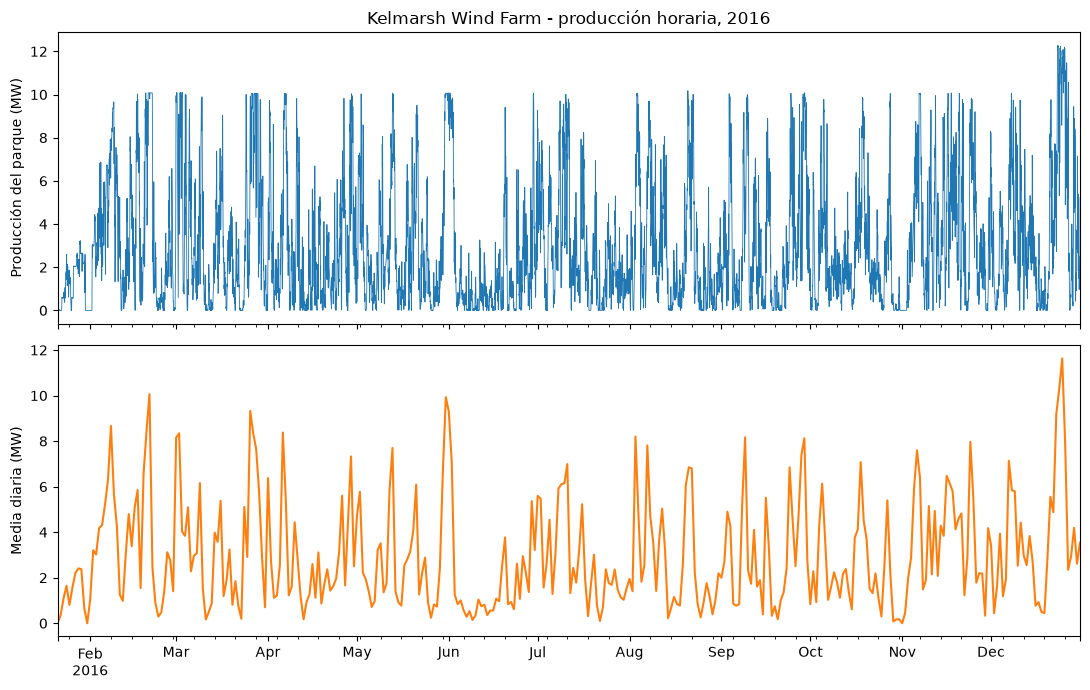

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
farm_production["output_mw"].plot(ax=axes[0], lw=0.6, color="tab:blue")
axes[0].set_ylabel("Producción del parque (MW)")
axes[0].set_title(f"{farm.name} - producción horaria, 2016")

farm_production["output_mw"].resample("1D").mean().plot(ax=axes[1], color="tab:orange")
axes[1].set_ylabel("Media diaria (MW)")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

Estacionalidad visible (otoño/invierno más ventoso que primavera/verano) - esto importa más
adelante tanto para la elección del split train/test (§3) como para el análisis de drift (§8): un
modelo evaluado en una estación distinta a la que entrenó está siendo evaluado sobre una
distribución de entrada genuinamente diferente, no solo "tiempo nuevo".

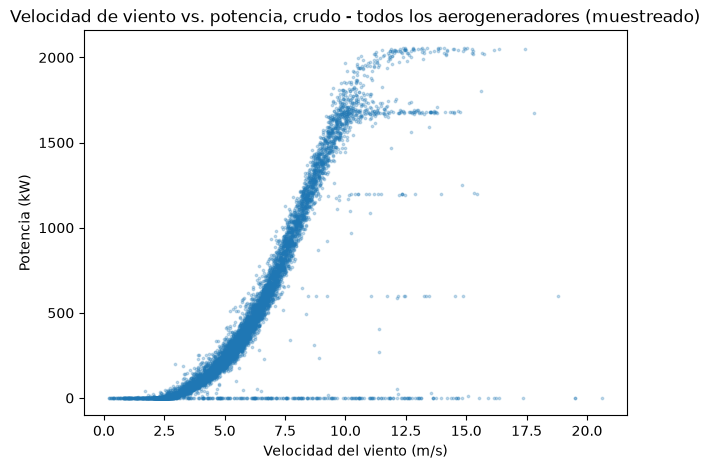

In [7]:
# Relación cruda velocidad de viento vs. potencia, datos horarios por aerogenerador (remuestreados desde 10 min) -
# debería mostrar la forma clásica de una curva de potencia real: arranque / rampa cúbica / meseta a potencia nominal / corte.
fig, ax = plt.subplots(figsize=(7, 5))
sample = turbine_hourly.sample(min(8000, len(turbine_hourly)), random_state=42)
ax.scatter(sample["wind_speed_ms"], sample["power_kw"], s=3, alpha=0.25, color="tab:blue")
ax.set_xlabel("Velocidad del viento (m/s)")
ax.set_ylabel("Potencia (kW)")
ax.set_title("Velocidad de viento vs. potencia, crudo - todos los aerogeneradores (muestreado)")
plt.show()

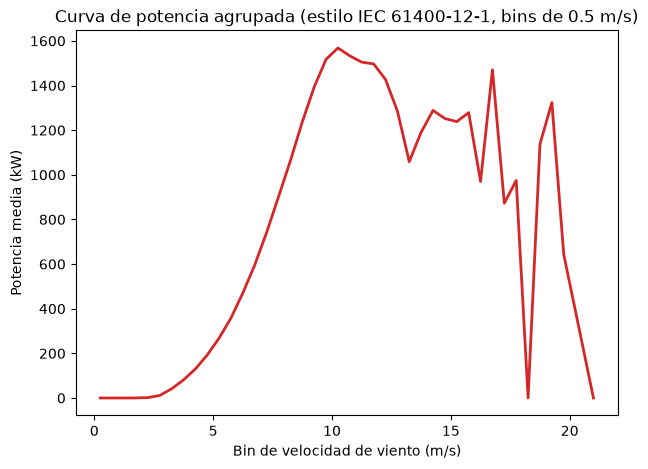

,mean_power_kw,sample_count
wind_speed_bin,,
0.25,0.000000,94
0.75,0.000000,255
1.25,0.042768,416
1.75,0.352916,592
2.25,1.743928,1546
2.75,11.298492,2176
3.25,40.985828,2381
3.75,80.874106,2914


In [8]:
# La misma relación, agrupada al estilo IEC 61400-12-1 (analysis/efficiency.py) - la curva de potencia
# de producción usada más adelante para benchmarking de eficiencia y detección de anomalías.
farm_curve = binned_power_curve(turbine_hourly, power_col="power_kw")
fig, ax = plt.subplots(figsize=(7, 5))
c = farm_curve.dropna()
ax.plot(c.index, c["mean_power_kw"], color="tab:red", lw=2)
ax.set_xlabel("Bin de velocidad de viento (m/s)")
ax.set_ylabel("Potencia media (kW)")
ax.set_title("Curva de potencia agrupada (estilo IEC 61400-12-1, bins de 0.5 m/s)")
plt.show()
farm_curve.dropna().head(8)

<a id="3"></a>
## 3. Preparación de Datos e Ingeniería de Variables

En lugar de re-derivar aquí la lógica de unión/creación de variables, esta celda llama a la
**función real del pipeline de producción**, `forecasting.pipeline.build_training_frame(farm)`:

- carga la producción SCADA real del parque,
- obtiene el histórico meteorológico real de ERA5 para las mismas coordenadas/período (Open-Meteo),
- une el precio day-ahead,
- llama a `forecasting.features.add_derived_features` para añadir las columnas derivadas de la física, y
- descarta filas con variables/objetivo faltantes.

Esta es exactamente la función que el bloque `__main__` de `forecasting/train.py` llama antes de
entrenar - usarla aquí significa que la preparación de datos de este notebook nunca puede
divergir silenciosamente de lo que hace producción.

In [9]:
from forecasting.pipeline import build_training_frame
from forecasting.features import FEATURE_COLUMNS, TARGET_COLUMN, add_derived_features

df = build_training_frame(farm)
print(f"Frame de entrenamiento: {df.shape[0]} filas horarias, {df.index.min()} -> {df.index.max()}")
df[FEATURE_COLUMNS + [TARGET_COLUMN]].describe().T

Frame de entrenamiento: 8174 filas horarias, 2016-01-21 14:00:00 -> 2016-12-31 23:00:00


,count,mean,std,min,25%,50%,75%,max
wind_speed_ms,8174.0,4.319771,2.047556,0.140000,2.792500,3.970000,5.590000,12.320000
wind_speed_cubed,8174.0,141.384727,209.588169,0.002744,21.776229,62.570773,174.676879,1869.959168
wind_direction_deg,8174.0,201.033888,96.106231,1.000000,131.000000,225.000000,269.000000,360.000000
temperature_c,8174.0,10.186628,5.910968,-4.300000,5.500000,9.900000,14.700000,28.800000
pressure_hpa,8174.0,1015.893112,10.255703,971.100000,1009.500000,1017.100000,1022.600000,1044.600000
air_density_kg_m3,8174.0,1.249621,0.029220,1.165204,1.226835,1.249600,1.268851,1.340637
price_eur_mwh,8174.0,73.345233,25.492317,3.699736,46.693700,83.277881,93.017380,126.954089
hour_of_day,8174.0,11.512601,6.928558,0.000000,6.000000,12.000000,18.000000,23.000000
output_mw,8174.0,3.007214,2.865105,0.000000,0.757859,2.079163,4.500229,12.268583


### Recurso eólico del emplazamiento y producción del parque vs. velocidad de viento

Antes de definir las variables del modelo, una vista rápida de evaluación del recurso del propio
emplazamiento: el panel superior es la distribución observada de la velocidad de viento (de la
misma serie ERA5 que alimenta al modelo), superpuesta con una distribución de Weibull ajustada -
la forma estándar en la industria de caracterizar el recurso eólico. El panel inferior comparte el
mismo eje x (velocidad de viento) y muestra la producción real del parque como una fracción de su
potencia nominal total a cada velocidad de viento - es decir, la curva de potencia real, basada en
ERA5, de la que este modelo está aprendiendo.

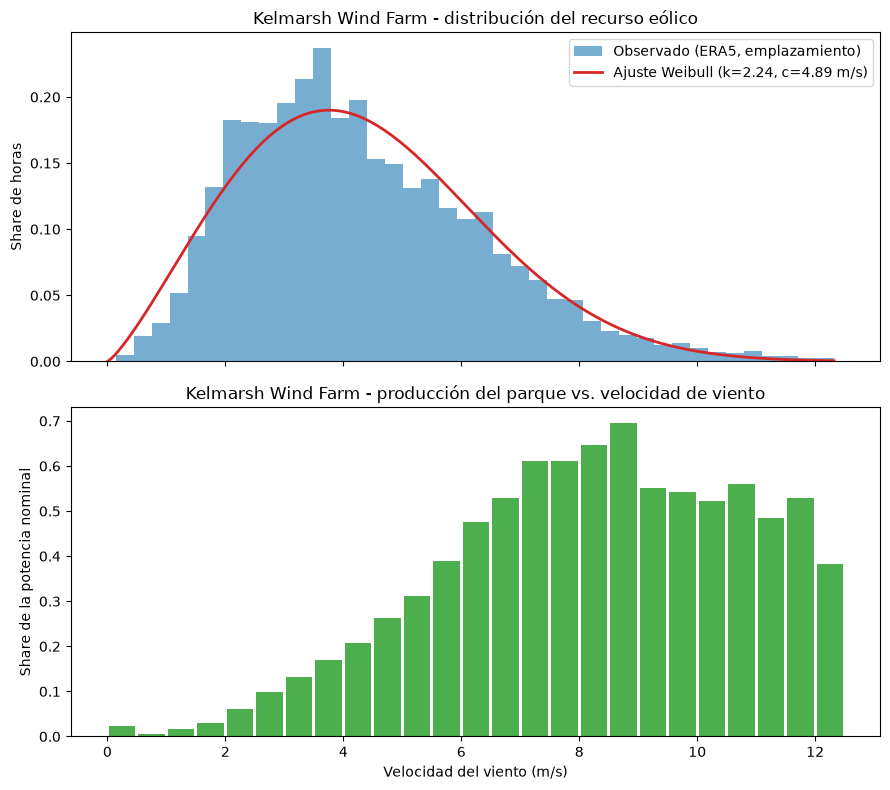

In [10]:
from scipy.stats import weibull_min

wind_speed = df["wind_speed_ms"]
weibull_shape, weibull_loc, weibull_scale = weibull_min.fit(wind_speed, floc=0)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Arriba: distribución de la velocidad de viento (share de horas) + ajuste Weibull
axes[0].hist(wind_speed, bins=40, density=True, color="tab:blue", alpha=0.6, label="Observado (ERA5, emplazamiento)")
x = np.linspace(0, wind_speed.max(), 200)
axes[0].plot(x, weibull_min.pdf(x, weibull_shape, weibull_loc, weibull_scale), color="tab:red", lw=2,
             label=f"Ajuste Weibull (k={weibull_shape:.2f}, c={weibull_scale:.2f} m/s)")
axes[0].set_ylabel("Share de horas")
axes[0].set_title(f"{farm.name} - distribución del recurso eólico")
axes[0].legend()

# Abajo: producción del parque vs. velocidad de viento, media por bin como fracción de la potencia nominal total
bins = np.arange(0, wind_speed.max() + 1, 0.5)
bin_labels = bins[:-1] + 0.25
power_binned = df.groupby(pd.cut(wind_speed, bins=bins), observed=True)["output_mw"].mean()
total_capacity_mw = farm.rated_power_kw * len(farm.turbine_ids) / 1000
share_of_capacity = (power_binned / total_capacity_mw).reindex(bin_labels, fill_value=np.nan)

axes[1].bar(bin_labels, share_of_capacity.values, width=0.45, color="tab:green", alpha=0.85)
axes[1].set_xlabel("Velocidad del viento (m/s)")
axes[1].set_ylabel("Share de la potencia nominal")
axes[1].set_title(f"{farm.name} - producción del parque vs. velocidad de viento")

plt.tight_layout()
plt.show()

### Definición de variables (de `forecasting/features.py`, reutilizadas tal cual)

| Variable | Justificación |
|---|---|
| `wind_speed_ms` | Principal factor determinante de la producción |
| `wind_speed_cubed` | La potencia cinética del viento escala con v³ (`P = 0.5 · ρ · A · v³`) - una variable no lineal motivada por la física, no algo que se deja para que un modelo de árboles la redescubra |
| `wind_direction_deg` | Los efectos de estela / abrigo del terreno dependen de la dirección, no solo de la velocidad |
| `temperature_c`, `pressure_hpa` | Entradas para la densidad del aire real (abajo) - aire más frío y denso transporta más energía cinética por m³ a la misma velocidad de viento |
| `air_density_kg_m3` | Calculada mediante la **ley de los gases ideales** (`analysis/efficiency.air_density_kg_m3`) a partir de la temperatura/presión real por hora, en lugar de asumir la constante estándar a nivel del mar de 1.225 kg/m³ - las condiciones reales de un parque pueden divergir lo suficiente como para importar |
| `price_eur_mwh` | No es un factor de la producción *física*, pero permite que el modelo (y la capa de negocio) razone conjuntamente sobre la producción y su valor de mercado |
| `hour_of_day` | Captura patrones diurnos tanto en el precio como (débilmente) en el régimen de viento |

### Relevancia de las variables

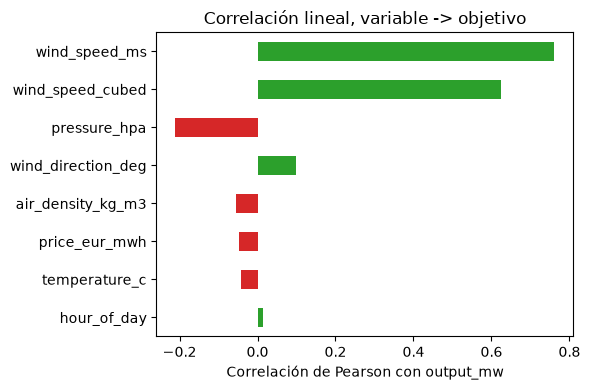

wind_speed_ms         0.761548
wind_speed_cubed      0.623267
pressure_hpa         -0.210663
wind_direction_deg    0.099148
air_density_kg_m3    -0.055856
price_eur_mwh        -0.046339
temperature_c        -0.042172
hour_of_day           0.013035
Name: output_mw, dtype: float64

In [11]:
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
corr.plot(kind="barh", ax=ax, color=["tab:green" if v > 0 else "tab:red" for v in corr])
ax.set_xlabel("Correlación de Pearson con output_mw")
ax.set_title("Correlación lineal, variable -> objetivo")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
corr

`wind_speed_ms` y `wind_speed_cubed` están (como es esperable) fuertemente correlacionadas con la
producción y entre sí - multicolinealidad casi de libro de texto. Las mantenemos ambas de todos
modos: los modelos basados en árboles (Random Forest / Gradient Boosting) no se ven perjudicados
por variables colineales, y para el baseline lineal es una decisión deliberada -
`wind_speed_cubed` sola se usa *también* como baseline puramente físico en el §4, así que comparar
"lineal con ambas" vs. "lineal solo con v³" es en sí mismo parte de la evaluación, no un error de
modelado a corregir.

### Split train/test - una desviación deliberada de producción, y por qué

`forecasting/train.py` actualmente usa un `train_test_split` **aleatorio** 80/20 (más validación
cruzada k-fold sobre el 80%) para seleccionar y reportar su métrica de test. Para un proceso
genuinamente dependiente del tiempo con estacionalidad fuerte (§2), un split aleatorio permite que
horas del conjunto de test de todas las estaciones se filtren al entrenamiento, lo que
**sobreestima** cuanto generalizará el modelo a un período futuro real que nunca ha visto. Para
las métricas principales de este caso de estudio, usamos en su lugar un **split cronológico** -
entrenar con el primer 80% del año, evaluar con el último 20% (una ventana futura real, nunca
vista) - y mantenemos la validación cruzada k-fold aleatoria junto a él precisamente para hacer
visible esa diferencia (ver §5). Esto se señala explícitamente como una recomendación para el
script de entrenamiento de producción, no se "corrige" allí silenciosamente.

In [12]:
split_idx = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]
X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]

print(f"Train: {len(train_df)} filas, {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test:  {len(test_df)} filas,  {test_df.index.min().date()} -> {test_df.index.max().date()}")

Train: 6539 filas, 2016-01-21 -> 2016-10-22
Test:  1635 filas,  2016-10-22 -> 2016-12-31


<a id="4"></a>
## 4. Modelado - Baselines vs. Modelos Candidatos

**Dos baselines**, del más simple al más exigente:
1. **Media climatológica** - predecir la media del período de entrenamiento para cada hora. El
   suelo mínimo que cualquier modelo debe superar.
2. **Solo física** - un ajuste lineal de una sola variable de la producción sobre `wind_speed_cubed`
   (es decir, "confiar simplemente en la ley de v³"). Significativamente más difícil de superar
   que el #1, y un chequeo de sanidad genuinamente útil: si un modelo complejo no puede superar la
   física pura, la complejidad extra no se está justificando.

**Tres modelos entrenados**, de menor a mayor complejidad:
- **Regresión Lineal** (todas las variables) - punto de referencia interpretable.
- **Random Forest Regressor** - captura no linealidades/interacciones con un ajuste mínimo.
- **Gradient Boosting Regressor**, configurado con los **hiperparámetros exactos que
  `forecasting/train.py` usa en producción** (`n_estimators=200, max_depth=4, learning_rate=0.05`)
  - esta es literalmente la clase de modelo y configuración que Windward entrena y registra por
  cada parque.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.base import clone

def mape(y_true, y_pred):
    denom = np.where(y_true == 0, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom))

results, predictions = [], {}

def evaluate(name, y_true, y_pred):
    predictions[name] = y_pred
    results.append({
        "model": name,
        "mae_mw": mean_absolute_error(y_true, y_pred),
        "rmse_mw": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "mape": mape(y_true.values, y_pred),
    })

# --- Baselines ---
evaluate("Baseline: media climatológica", y_test, np.full(len(y_test), y_train.mean()))

physics_model = LinearRegression().fit(X_train[["wind_speed_cubed"]], y_train)
evaluate("Baseline: solo física (v³)", y_test, physics_model.predict(X_test[["wind_speed_cubed"]]))

# --- Modelos entrenados ---
lin_model = LinearRegression().fit(X_train, y_train)
evaluate("Regresión Lineal (todas las variables)", y_test, lin_model.predict(X_test))

rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1).fit(X_train, y_train)
evaluate("Random Forest", y_test, rf_model.predict(X_test))

# Coincide exactamente con la configuración de producción de forecasting/train.py
GBR_PARAMS = dict(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbr_model = GradientBoostingRegressor(**GBR_PARAMS).fit(X_train, y_train)
evaluate("Gradient Boosting (config. de producción)", y_test, gbr_model.predict(X_test))

results_df = pd.DataFrame(results).set_index("model").sort_values("mae_mw")
results_df.style.format({"mae_mw": "{:.3f}", "rmse_mw": "{:.3f}", "r2": "{:.3f}", "mape": "{:.1%}"})

,mae_mw,rmse_mw,r2,mape
model,,,,
Random Forest,1.523,2.304,0.458,342.5%
Regresión Lineal (todas las variables),1.525,2.075,0.560,1299.2%
Gradient Boosting (config. de producción),1.552,2.335,0.443,388.6%
Baseline: solo física (v³),1.919,2.485,0.369,2345.5%
Baseline: media climatológica,2.489,3.209,-0.052,3820.0%


In [14]:
# Validación cruzada k-fold sobre el split de entrenamiento - mismo patrón que corre forecasting/train.py
# (KFOLD_SPLITS=5, con shuffle, random_state=42) como chequeo adicional de generalización de menor varianza.
KFOLD_SPLITS = 5
kf = KFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=42)
fold_r2 = []
for tr_idx, te_idx in kf.split(X_train):
    m = clone(gbr_model)
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    fold_r2.append(r2_score(y_train.iloc[te_idx], m.predict(X_train.iloc[te_idx])))

print(f"Gradient Boosting - R² de CV k-fold (splits aleatorios dentro de train): {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}")
print(f"Gradient Boosting - R² del split cronológico de test (período futuro no visto): {results_df.loc['Gradient Boosting (config. de producción)', 'r2']:.3f}")

Gradient Boosting - R² de CV k-fold (splits aleatorios dentro de train): 0.759 +/- 0.017
Gradient Boosting - R² del split cronológico de test (período futuro no visto): 0.443


### Interpretando la comparación

- **Los tres modelos entrenados superan comodamente a ambos baselines en MAE/RMSE** - el R²
  cercano a cero o negativo del baseline de media, junto a su MAE mucho mayor, confirman que el
  problema de predicción es real y que las variables llevan señal genuina. El baseline de solo
  física es un suelo significativamente más difícil de superar (como se pretendía) pero aun así
  pierde claramente frente a todos los modelos entrenados.
- **Regresión Lineal, Random Forest y Gradient Boosting quedan dentro de ~1% de MAE entre sí** en
  este parque/año - la relación está dominada por unas pocas variables fuertemente motivadas por
  la física, así que la capacidad extra del modelo compra relativamente poca precisión adicional
  aquí. Eso es en sí mismo un hallazgo legítimo y útil, no un resultado nulo.
- **El R² y el MAPE discrepan visiblemente en el ranking de modelos.** El MAPE divide por el valor
  *real*, así que las horas con producción real cercana a cero (períodos de calma) disparan el
  error porcentual incluso para desviaciones absolutas mínimas - el MAPE mucho mayor de la
  Regresión Lineal pese a tener un R² *mejor* que Random Forest/GBR es exactamente ese artefacto,
  no evidencia de que sea un modelo peor. Por eso la métrica de negocio principal del §5 se
  construye sobre el error *absoluto* (§1), no sobre el MAPE.
- **El R² de la CV k-fold (con mezcla aleatoria) resulta significativamente mayor que el R² del
  split cronológico de test.** La mezcla aleatoria filtra horas de todas las estaciones tanto al
  pliegue de entrenamiento como al de validación, por lo que sobreestima la precisión real hacia
  adelante; el split cronológico es el número honesto para "cómo rendiría esto en un período
  futuro genuinamente nuevo" y coincide con el hallazgo de drift estacional del §8.
  **Recomendación para producción:** es probable que el `mae_mw`/`r2` que reporta el propio
  `forecasting/train.py` (también de un split aleatorio) tenga el mismo sesgo optimista, y valdría
  la pena cambiar también allí a una evaluación cronológica o con `TimeSeriesSplit`.
- **Gradient Boosting se mantiene como el modelo elegido de cara al futuro** - no porque gane por
  un margen amplio aquí (no lo hace), sino porque coincide con lo que ya está registrado y sirviendo
  en producción, ofrece importancias de variables nativas (abajo), y tiende a ser más robusto a
  medida que se añaden más parques/estaciones/años de datos con el tiempo que un modelo lineal simple.

<a id="5"></a>
## 5. Resultados y Evaluación

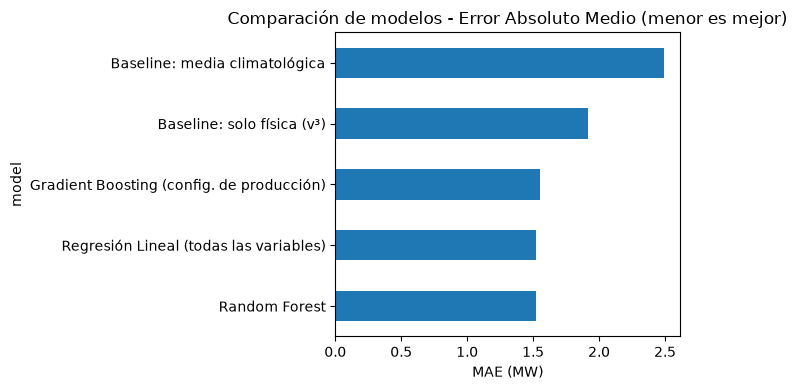

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df["mae_mw"].sort_values().plot(kind="barh", ax=ax, color="tab:blue")
ax.set_xlabel("MAE (MW)")
ax.set_title("Comparación de modelos - Error Absoluto Medio (menor es mejor)")
plt.tight_layout()
plt.show()

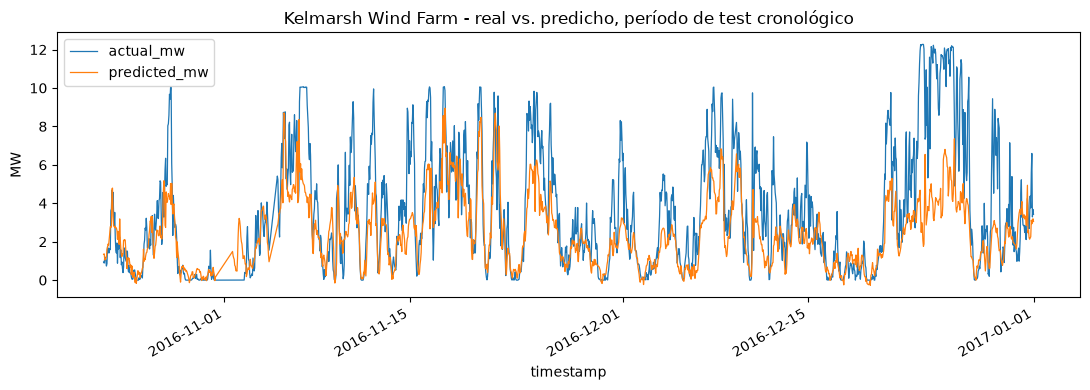

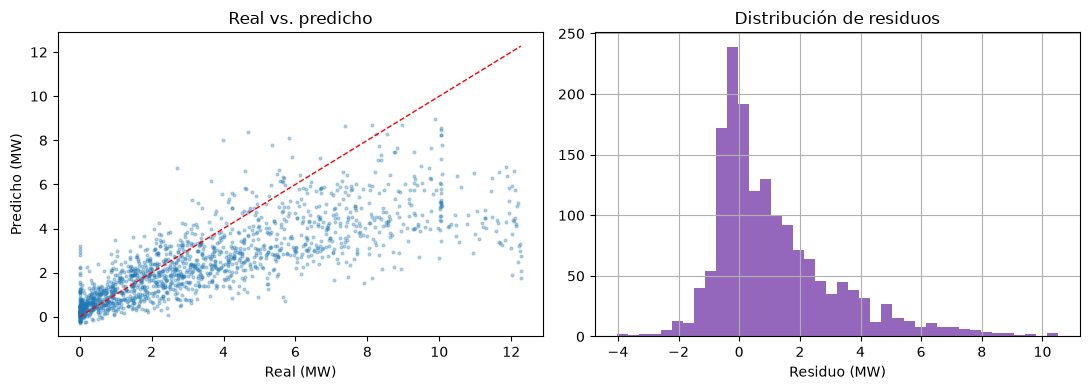

In [16]:
from analysis.efficiency import actual_vs_predicted

best_pred = pd.Series(predictions["Gradient Boosting (config. de producción)"], index=y_test.index)
comparison = actual_vs_predicted(y_test, best_pred)  # helper de producción reutilizado: alinea + añade columnas de residuo/porcentaje

fig, ax = plt.subplots(figsize=(11, 4))
comparison[["actual_mw", "predicted_mw"]].plot(ax=ax, lw=0.9)
ax.set_ylabel("MW")
ax.set_title(f"{farm.name} - real vs. predicho, período de test cronológico")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(comparison["actual_mw"], comparison["predicted_mw"], s=4, alpha=0.3)
lims = [0, comparison["actual_mw"].max()]
axes[0].plot(lims, lims, color="red", lw=1, ls="--")
axes[0].set_xlabel("Real (MW)"); axes[0].set_ylabel("Predicho (MW)"); axes[0].set_title("Real vs. predicho")

comparison["residual_mw"].hist(ax=axes[1], bins=40, color="tab:purple")
axes[1].set_xlabel("Residuo (MW)"); axes[1].set_title("Distribución de residuos")
plt.tight_layout()
plt.show()

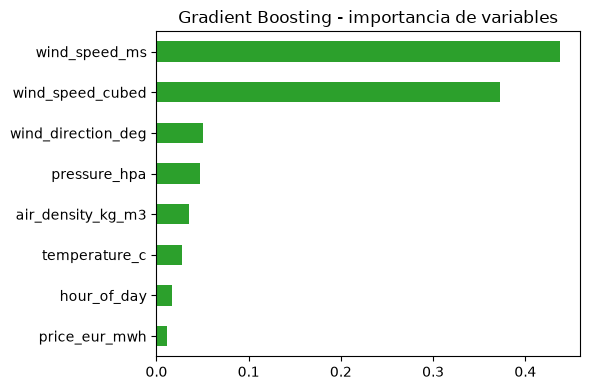

In [17]:
# Importancia de variables del modelo con la configuración de producción
importances = pd.Series(gbr_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax, color="tab:green")
ax.set_title("Gradient Boosting - importancia de variables")
plt.tight_layout()
plt.show()

### Métrica de negocio: proxy de coste por desvío

Convertir el error absoluto de predicción a € usando el precio day-ahead (sintético, ver §2) da
un número directamente legible para el negocio en lugar de una cifra abstracta en MW - este es el
número que se traduciría en un coste real de liquidación por desvío si un parque ofertara estas
predicciones en el mercado.

In [18]:
def imbalance_cost_eur(comparison_df, price_series):
    aligned_price = price_series.reindex(comparison_df.index)
    return float((comparison_df["residual_mw"].abs() * aligned_price).sum())

baseline_comparison = actual_vs_predicted(y_test, pd.Series(np.full(len(y_test), y_train.mean()), index=y_test.index))

model_cost = imbalance_cost_eur(comparison, test_df["price_eur_mwh"])
baseline_cost = imbalance_cost_eur(baseline_comparison, test_df["price_eur_mwh"])
reduction = 1 - model_cost / baseline_cost

from IPython.display import Markdown, display
display(Markdown(
    f"Durante el período de test cronológico de **{len(test_df)} horas**:\n\n"
    f"- Proxy de coste por desvío del baseline de media climatológica: **€{baseline_cost:,.0f}**\n"
    f"- Proxy de coste por desvío del modelo Gradient Boosting: **€{model_cost:,.0f}**\n"
    f"- **Reducción del {reduction:.0%}** en la exposición por desvío frente al baseline ingenuo, para este parque y período."
))

Durante el período de test cronológico de **1635 horas**:

- Proxy de coste por desvío del baseline de media climatológica: **€297,802**
- Proxy de coste por desvío del modelo Gradient Boosting: **€190,770**
- **Reducción del 36%** en la exposición por desvío frente al baseline ingenuo, para este parque y período.

<a id="6"></a>
## 6. Eficiencia y Diagnóstico Físico (extra, reutilizando `analysis/efficiency.py`)

Más allá de la propia predicción, el módulo `analysis/efficiency.py` de Windward ejecuta
diagnósticos reales de la industria eólica (agrupación de la curva de potencia al estilo IEC
61400-12-1, benchmarking del coeficiente de potencia frente al límite de Betz, detección de
bajo rendimiento entre aerogeneradores vecinos mediante KD-tree) que convierten los datos SCADA en
hallazgos operacionales. Estos alimentan directamente los hallazgos del §9 - reutilizados aquí
exactamente igual que en producción (los nodos `diagnose`/`investigate` de `agents/graph.py`
llaman a las mismas funciones).

In [19]:
from analysis.efficiency import (
    turbine_efficiency_summary, fit_power_curve_displacement,
    neighbor_underperformance, scada_reanalysis_wind_check,
)

# Densidad del aire real por hora (ley de los gases ideales) en lugar de la constante a nivel del mar
air_density_by_ts = air_density_kg_m3(df["temperature_c"], df["pressure_hpa"])

eff_summary = turbine_efficiency_summary(turbine_hourly, farm.rated_power_kw, farm.rotor_diameter_m, air_density_by_ts)
eff_summary.style.format({"capacity_factor": "{:.1%}", "peak_cp": "{:.3f}", "betz_limit": "{:.3f}"})

,capacity_factor,peak_cp,betz_limit,hours_observed
turbine_id,,,,
Kelmarsh_1,25.4%,0.531,0.593,8101
Kelmarsh_2,30.0%,0.536,0.593,8103
Kelmarsh_3,24.7%,0.542,0.593,7897
Kelmarsh_4,26.6%,0.539,0.593,7834
Kelmarsh_5,23.2%,0.594,0.593,7982
Kelmarsh_6,20.7%,0.537,0.593,7786


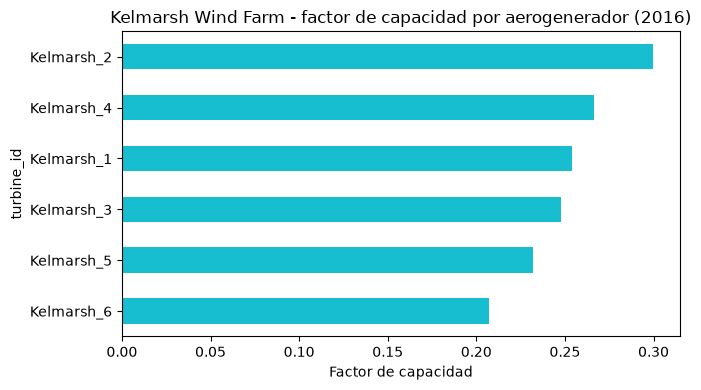

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
eff_summary["capacity_factor"].sort_values().plot(kind="barh", ax=ax, color="tab:cyan")
ax.set_xlabel("Factor de capacidad")
ax.set_title(f"{farm.name} - factor de capacidad por aerogenerador (2016)")
plt.tight_layout()
plt.show()

In [21]:
# La curva de potencia del aerogenerador con peor rendimiento está genuinamente desplazada (sesgo del anemómetro)
# respecto a la curva de referencia del parque, o está pasando otra cosa?
worst_turbine = eff_summary["capacity_factor"].idxmin()
worst_series = turbine_hourly[turbine_hourly["turbine_id"] == worst_turbine]
displacement = fit_power_curve_displacement(farm_curve, worst_series["wind_speed_ms"], worst_series["power_kw"])
print(f"Menor factor de capacidad: {worst_turbine} ({eff_summary.loc[worst_turbine, 'capacity_factor']:.1%})")
print(f"Desplazamiento de la curva de potencia vs. referencia del parque: {displacement:+.2f} m/s")

# Bajo rendimiento por aerogenerador y por hora vs. los k=5 vecinos espaciales más cercanos (KD-tree)
flagged_hours = neighbor_underperformance(turbine_hourly, turbine_static)
pd.Series(flagged_hours, name="horas_bajas_marcadas").sort_values(ascending=False).to_frame()

Menor factor de capacidad: Kelmarsh_6 (20.7%)
Desplazamiento de la curva de potencia vs. referencia del parque: +0.06 m/s


,horas_bajas_marcadas
Kelmarsh_6,1227
Kelmarsh_3,569
Kelmarsh_1,526
Kelmarsh_5,374
Kelmarsh_4,244
Kelmarsh_2,203


In [22]:
# Chequeo cruzado independiente de calidad de datos: velocidad media del viento SCADA del parque vs. el
# reanálisis independiente de Open-Meteo para las mismas horas - un chequeo real con una segunda fuente,
# no un chequeo de autoconsistencia.
qc = scada_reanalysis_wind_check(turbine_hourly, df)
qc

{'correlation': 0.8992179553099439,
 'hours_compared': 8174,
 'mean_abs_diff_ms': 1.807880709212177,
 'pct_hours_diverging_gt_5ms': 0.006361634450697333}

<a id="7"></a>
## 7. Pipeline, Reproducibilidad y Despliegue en Producción

**Este caso de estudio no es un análisis aislado de notebook - es una capa analítica delgada sobre
una base de código real y modular que ya corre en producción.** Todo lo importado arriba
(`data_sources.*`, `forecasting.*`, `analysis.efficiency`) es un módulo real del proyecto con su
propia responsabilidad, testeable de forma independiente y ya cubierto por `tests/`.

In [23]:
MÓDULOS = {
    "config.py":                    "Configuración central desde variables de entorno / .env - sin endpoints/secretos hardcodeados",
    "data_sources/farms.py":        "Registro de parques (dataclass) - coordenadas, potencia nominal, que loader SCADA aplica",
    "data_sources/greenbyte_scada.py / hill_of_towie_scada.py": "Parsers SCADA específicos de formato tras una interfaz compartida (loader_for)",
    "data_sources/meteo_client.py": "Cliente meteorológico (Open-Meteo), reintento con backoff en errores 5xx transitorios",
    "data_sources/energy_price_client.py": "Cliente de precio day-ahead, ENTSO-E real con fallback sintético",
    "forecasting/features.py":      "Fuente única de verdad para las columnas de variables - importada tanto por entrenamiento como por inferencia para que no puedan divergir",
    "forecasting/pipeline.py":      "Construye el frame de entrenamiento (usado directamente en este notebook, §3)",
    "forecasting/train.py":         "Entrena + registra en MLflow + registra el modelo",
    "forecasting/registry.py":      "Carga la última versión registrada del modelo para inferencia",
    "forecasting/predict.py":       "Inferencia por lotes: meteorología/precio pronosticados -> modelo registrado -> ForecastResult",
    "analysis/efficiency.py":       "Diagnósticos de física/estadística reutilizados a lo largo de este notebook (§2, §6)",
    "schemas/models.py":            "Contratos Pydantic compartidos por cada frontera de módulo y por la API",
    "api/main.py":                  "Servicio FastAPI que expone /forecast y el dashboard en vivo",
    "agents/graph.py":              "Flujo LangGraph: ingest -> forecast -> diagnose -> investigate -> recommend/recommend_retrain -> explain",
    "tests/":                       "Suite de pytest (schemas, API)",
}
for path, desc in MÓDULOS.items():
    print(f"{path:<46} {desc}")

config.py                                      Configuración central desde variables de entorno / .env - sin endpoints/secretos hardcodeados
data_sources/farms.py                          Registro de parques (dataclass) - coordenadas, potencia nominal, que loader SCADA aplica
data_sources/greenbyte_scada.py / hill_of_towie_scada.py Parsers SCADA específicos de formato tras una interfaz compartida (loader_for)
data_sources/meteo_client.py                   Cliente meteorológico (Open-Meteo), reintento con backoff en errores 5xx transitorios
data_sources/energy_price_client.py            Cliente de precio day-ahead, ENTSO-E real con fallback sintético
forecasting/features.py                        Fuente única de verdad para las columnas de variables - importada tanto por entrenamiento como por inferencia para que no puedan divergir
forecasting/pipeline.py                        Construye el frame de entrenamiento (usado directamente en este notebook, §3)
forecasting/train.py            

### Reproducibilidad
- **Dependencias fijadas** (`requirements.txt`), un `Dockerfile` con versión de Python fijada
  (`python:3.12-slim`), de modo que el mismo entorno corre en local y en el contenedor desplegado.
- **Sin constantes hardcodeadas** - las coordenadas/potencia nominal/lista de aerogeneradores de
  cada parque viven en un único registro dataclass (`data_sources/farms.py`); añadir un parque
  significa añadir una entrada `Farm(...)`, sin tocar el código de modelado. Cada modelo mostrado
  aquí correría idénticamente para `penmanshiel` o `hill_of_towie` con solo cambiar `FARM_ID`.
- **Semillas aleatorias fijas** (`random_state=42`) en todo el entrenamiento/particionado para
  resultados repetibles.
- **Definiciones de variables compartidas** (`forecasting/features.py`) significan que
  entrenamiento e inferencia nunca pueden calcular una variable de forma distinta sin darse cuenta
  - una fuente común y difícil de detectar de discrepancia entre entrenamiento y servicio.
- **Tests** (`tests/`) cubren los contratos de la API y de los esquemas, de modo que un despliegue
  roto falla en CI, no en un usuario.

### Cómo correría esto en producción (ya corre así, para el servicio en vivo)

```python
# forecasting/train.py - entrenamiento + registro (programado, o disparado por drift - ver §8)
model.fit(X_train, y_train)
mlflow.sklearn.log_model(model, artifact_path="model",
                          registered_model_name=f"windward-production-forecast-{farm_id}")

# forecasting/registry.py - la inferencia siempre carga la versión registrada *más reciente*
mlflow.pyfunc.load_model(f"models:/{name}/latest")

# api/main.py - endpoint real, respaldado por el registro anterior
@app.post("/forecast", response_model=ForecastResult)
def forecast(request: ForecastRequest):
    return predict_production(farm_id=request.farm_id, horizon_hours=request.horizon_hours)
```

**Forma del despliegue (implementado y en vivo en [windward.forwardforecasting.eu](https://windward.forwardforecasting.eu/)):**
- El entrenamiento corre **offline/bajo demanda**, registrando métricas/artefactos y una nueva
  versión del modelo en un **servidor de tracking de MLflow autoalojado** (almacén de artefactos
  en S3) - el entrenamiento nunca toca la ruta de servicio.
- El servicio **FastAPI** siempre resuelve `models:/<name>/latest` en el momento de la petición,
  así que promover un modelo recién entrenado a producción es una operación de registro, **no un
  redespliegue**.
- La API está contenerizada (`Dockerfile`, `docker-compose.prod.yml`) y corre de forma persistente
  en AWS detrás del dominio público; un **pipeline de CI/CD real** (`.github/workflows/deploy.yml`)
  ejecuta `pytest` en cada push a `master` y solo despliega (GitHub OIDC -> AWS SSM, sin claves SSH
  en ningún sitio) si los tests pasan, de modo que un modelo/esquema roto no pueda llegar al
  endpoint en vivo.
- Un **servidor MCP** (`mcp_server/`) expone las mismas herramientas de predicción/diagnóstico a
  cualquier cliente MCP (p. ej. Claude), y el **agente LangGraph** (`agents/graph.py`) envuelve la
  predicción con la capa de diagnóstico/recomendación descrita en el §1 y el §8.

<a id="8"></a>
## 8. Monitorización, Detección de Drift y Estrategia de Reentrenamiento

Dos modos de fallo distintos a vigilar en producción, ambos implementados abajo:

1. **Drift de datos (variables)** - la distribución de las entradas se desplaza respecto a lo que
   el modelo vio en entrenamiento (p. ej. una estación que la ventana de entrenamiento no cubría,
   una recalibración de sensor, un nuevo modelo de aerogenerador añadido a la flota). Se detecta
   *antes* de que necesariamente se traduzca en peor precisión.
2. **Drift de concepto / rendimiento** - el error de predicción real del modelo crece con el
   tiempo, se haya movido visiblemente o no la distribución de alguna variable individual. Esto es
   lo que en última instancia importa operacionalmente, y es exactamente lo que **ya corre en el
   agente en vivo** (el `investigate_node` de `agents/graph.py`) - reutilizado aquí directamente.

In [24]:
from scipy.stats import ks_2samp

def population_stability_index(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    # PSI: puntuación estándar de magnitud de drift. <0.1 sin cambio significativo, 0.1-0.2 moderado,
    # >0.2 significativo - umbrales convencionales de la industria.
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e_pct = np.clip(np.histogram(expected, bins=edges)[0] / len(expected), 1e-4, None)
    a_pct = np.clip(np.histogram(actual, bins=edges)[0] / len(actual), 1e-4, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

drift_rows = []
for col in FEATURE_COLUMNS:
    stat, pvalue = ks_2samp(train_df[col], test_df[col])
    drift_rows.append({
        "feature": col, "ks_stat": stat, "ks_pvalue": pvalue,
        "psi": population_stability_index(train_df[col].values, test_df[col].values),
    })
drift_df = pd.DataFrame(drift_rows).set_index("feature").sort_values("psi", ascending=False)
drift_df.style.format({"ks_stat": "{:.3f}", "ks_pvalue": "{:.2e}", "psi": "{:.3f}"}).background_gradient(subset=["psi"], cmap="Reds")

,ks_stat,ks_pvalue,psi
feature,,,
temperature_c,0.425,3.06e-213,2.145
air_density_kg_m3,0.490,2.16e-287,1.882
pressure_hpa,0.372,1.58e-162,0.794
wind_direction_deg,0.091,5.71e-10,0.080
wind_speed_ms,0.067,1.35e-05,0.027
wind_speed_cubed,0.067,1.35e-05,0.027
price_eur_mwh,0.023,5.09e-01,0.005
hour_of_day,0.007,1.00e+00,0.000


`temperature_c`, `air_density_kg_m3` y `pressure_hpa` muestran un drift grande y estadísticamente
significativo (train = con más peso de primavera/verano, test = los últimos meses del año, otoño/
invierno) - exactamente la estacionalidad señalada visualmente en el §2. Este es un buen ejemplo
de **drift esperado y cíclico**, no anómalo: la respuesta correcta es tener datos de entrenamiento
que cubran ciclos anuales completos (o una variable estacional explícita), no una alarma cada
otoño. Un monitor de PSI en producción necesitaría una **ventana de referencia lo bastante amplia
como para cubrir un ciclo estacional completo**, o "detectará drift" cada año según el calendario.
`wind_speed_ms`/`wind_speed_cubed` (los predictores más fuertes) y `price_eur_mwh` muestran
comparativamente poco drift aquí - tranquilizador para este split en concreto.

In [25]:
# Drift de concepto/rendimiento - el mismo patrón que ejecuta investigate_node de agents/graph.py en
# producción (MAPE de la ventana reciente vs. MAPE global), reutilizado aquí sin reimplementarlo.
GRAPH_SOURCE = (PROJECT_ROOT / "agents" / "graph.py").read_text()
start = GRAPH_SOURCE.index("def investigate_node")
end = GRAPH_SOURCE.index("def _route_after_investigation")
print(GRAPH_SOURCE[start:end].strip())

def investigate_node(state: WindwardState) -> dict:
    """Runs after rag+multimodal (both already in state by the time this fires — same
    fan-in guarantee the old rag/multimodal -> recommend edges gave recommend_node). Computes
    whether the forecast has gotten measurably worse recently and whether the registered model
    is old enough that retraining is worth flagging — real signals, not a fixed check."""
    from forecasting.registry import latest_model_info

    comparison = state["comparison"]
    abs_pct_err = (comparison["actual_mw"] - comparison["predicted_mw"]).abs() / comparison["predicted_mw"].replace(0, float("nan"))
    overall_mape = float(abs_pct_err.mean())
    recent_mape = float(abs_pct_err.tail(24 * 7).mean())  # last week of the SCADA period
    error_increased = recent_mape > overall_mape * RECENT_ERROR_INCREASE_RATIO

    model_info = latest_model_info(model_name(state["farm_id"]))
    stale = (model_info["age_days"] or 0) > RETRAIN_AGE_DAYS_THRESHOLD

    r

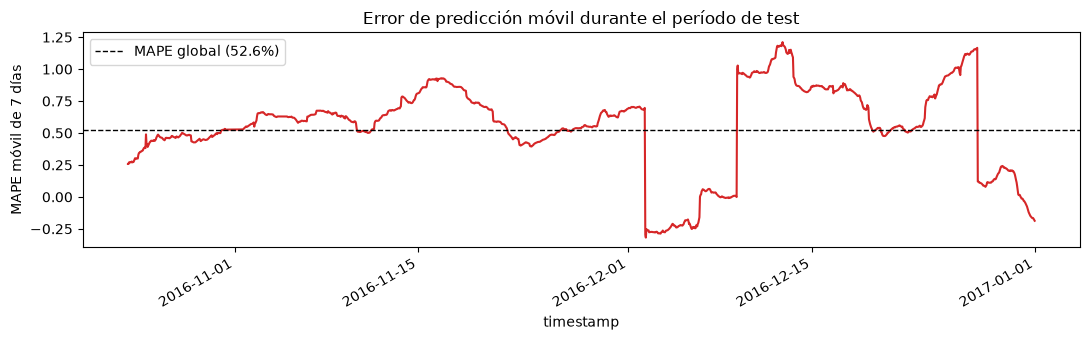

MAPE global: 52.6%, MAPE últimos 7 días: -18.7%, ratio: -0.36
Se marcaría 'error incrementado' según la regla de producción (ratio > 1.25): False


In [26]:
abs_pct_err = (comparison["actual_mw"] - comparison["predicted_mw"]).abs() / comparison["predicted_mw"].replace(0, np.nan)
overall_mape = float(abs_pct_err.mean())
recent_mape = float(abs_pct_err.tail(24 * 7).mean())  # última semana del período de test, misma ventana que usa investigate_node

fig, ax = plt.subplots(figsize=(11, 3.5))
abs_pct_err.rolling(24 * 7, min_periods=24).mean().plot(ax=ax, color="tab:red")
ax.axhline(overall_mape, color="black", ls="--", lw=1, label=f"MAPE global ({overall_mape:.1%})")
ax.set_ylabel("MAPE móvil de 7 días")
ax.set_title("Error de predicción móvil durante el período de test")
ax.legend()
plt.tight_layout()
plt.show()

# Mismos umbrales que usa agents/graph.py para decidir si recomendar un reentrenamiento
RECENT_ERROR_INCREASE_RATIO = 1.25   # de agents/graph.py
RETRAIN_AGE_DAYS_THRESHOLD = 90      # de agents/graph.py
error_increased = recent_mape > overall_mape * RECENT_ERROR_INCREASE_RATIO
print(f"MAPE global: {overall_mape:.1%}, MAPE últimos 7 días: {recent_mape:.1%}, ratio: {recent_mape/overall_mape:.2f}")
print(f"Se marcaría 'error incrementado' según la regla de producción (ratio > {RECENT_ERROR_INCREASE_RATIO}): {error_increased}")

### Estrategia de reentrenamiento (tal como está implementada en `agents/graph.py`, más recomendaciones)

**Hoy, en vivo:** `investigate_node` calcula el MAPE reciente vs. global (arriba) *y* comprueba la
antigüedad del modelo actualmente registrado vía `forecasting/registry.latest_model_info`
(consulta el registro de MLflow para la marca de tiempo de registro de la última versión). Solo
cuando **ambas** cosas ocurren - el error ha empeorado de forma medible **y** el modelo tiene más
de 90 días - el grafo enruta a `recommend_retrain_node` en lugar de la recomendación normal - esto
evita disparar un reentrenamiento por cada mala semana pasajera, o reentrenar un modelo que sigue
siendo genuinamente preciso solo porque ha pasado tiempo (umbrales deliberadamente ligeros,
"a escala de demo" - ver los comentarios del archivo; los umbrales reales se ajustarían contra un
histórico operativo más largo del que da un año de un solo parque).

**Aún no implementado, y que valdría la pena añadir a continuación:**
- **Reentrenamiento programado** (p. ej. mensual, o cada vez que hay disponible una estación
  completa nueva de datos) alimentando el mismo registro, de modo que el chequeo basado en
  antigüedad de arriba se apoye en una cadencia real y no solo en ejecuciones manuales.
- **Evaluación shadow/canary** - puntuar un candidato recién entrenado contra el modelo
  actualmente en servicio sobre la misma ventana reciente *antes* de promoverlo a `latest`, para
  que un reentrenamiento no pueda empeorar las cosas silenciosamente.
- **Rollback automático** - el registro de MLflow ya conserva cada versión anterior; una mala
  promoción es una reversión de una línea (`models:/<name>/<version_anterior>`), simplemente aún
  no está conectada a un disparador automático.

<a id="9"></a>
## 9. Hallazgos y Accionabilidad para el Negocio

In [27]:
from IPython.display import Markdown, display

worst_cf = eff_summary["capacity_factor"].idxmin()
best_cf = eff_summary["capacity_factor"].idxmax()
worst_val, best_val = eff_summary.loc[worst_cf, "capacity_factor"], eff_summary.loc[best_cf, "capacity_factor"]
worst_flagged = flagged_hours[worst_turbine]
mean_flagged_others = np.mean([v for t, v in flagged_hours.items() if t != worst_turbine])

display(Markdown(f'''
| # | Hallazgo | Evidencia | Acción recomendada |
|---|---|---|---|
| 1 | Gradient Boosting (con la configuración de producción) reduce el proxy de coste por desvío en un **{reduction:.0%}** frente a un baseline ingenuo de producción media | §5 | Confirma la propuesta de valor central del servicio de predicción en términos de €, no solo de MW |
| 2 | La precisión del split cronológico de test (R²={results_df.loc['Gradient Boosting (config. de producción)','r2']:.2f}) es significativamente menor que la precisión de la CV k-fold (R²={np.mean(fold_r2):.2f}) | §5 | Cambiar la métrica que reporta `forecasting/train.py` a una evaluación cronológica/`TimeSeriesSplit`, para que el número que aparece en MLflow refleje el rendimiento real hacia adelante |
| 3 | **{worst_turbine}** tiene el menor factor de capacidad de la flota ({worst_val:.1%} vs. el mejor {best_val:.1%}) y, por mucho, más horas de bajo rendimiento marcadas respecto a sus vecinos ({worst_flagged} vs. ~{mean_flagged_others:.0f} de media en el resto) | §6 | Priorizar la inspección física |
| 4 | ...pero el desplazamiento de la curva de potencia de ese mismo aerogenerador es de solo {displacement:+.2f} m/s - insignificante | §6 | Descarta una mala calibración del anemómetro como causa - apunta en su lugar a una causa mecánica/de estela/de paradas, lo que cambia que debería revisar una inspección |
| 5 | La velocidad media del viento del SCADA del parque correlaciona {qc['correlation']:.2f} con el reanálisis independiente de Open-Meteo para las mismas horas | §6 | Saludable - sin evidencia de un problema sistémico de sensores o de alineación de datos en la flota |
| 6 | Varias variables meteorológicas (temperatura, presión, densidad del aire) muestran un drift grande entre train/test (PSI ≥ {drift_df['psi'].iloc[0]:.2f}), pero sigue la estacionalidad conocida | §8 | No es, por sí solo, una falsa alarma - pero el monitor de drift en producción necesita una ventana de referencia que abarque un ciclo estacional completo |
'''))


| # | Hallazgo | Evidencia | Acción recomendada |
|---|---|---|---|
| 1 | Gradient Boosting (con la configuración de producción) reduce el proxy de coste por desvío en un **36%** frente a un baseline ingenuo de producción media | §5 | Confirma la propuesta de valor central del servicio de predicción en términos de €, no solo de MW |
| 2 | La precisión del split cronológico de test (R²=0.44) es significativamente menor que la precisión de la CV k-fold (R²=0.76) | §5 | Cambiar la métrica que reporta `forecasting/train.py` a una evaluación cronológica/`TimeSeriesSplit`, para que el número que aparece en MLflow refleje el rendimiento real hacia adelante |
| 3 | **Kelmarsh_6** tiene el menor factor de capacidad de la flota (20.7% vs. el mejor 30.0%) y, por mucho, más horas de bajo rendimiento marcadas respecto a sus vecinos (1227 vs. ~383 de media en el resto) | §6 | Priorizar la inspección física |
| 4 | ...pero el desplazamiento de la curva de potencia de ese mismo aerogenerador es de solo +0.06 m/s - insignificante | §6 | Descarta una mala calibración del anemómetro como causa - apunta en su lugar a una causa mecánica/de estela/de paradas, lo que cambia que debería revisar una inspección |
| 5 | La velocidad media del viento del SCADA del parque correlaciona 0.90 con el reanálisis independiente de Open-Meteo para las mismas horas | §6 | Saludable - sin evidencia de un problema sistémico de sensores o de alineación de datos en la flota |
| 6 | Varias variables meteorológicas (temperatura, presión, densidad del aire) muestran un drift grande entre train/test (PSI ≥ 2.15), pero sigue la estacionalidad conocida | §8 | No es, por sí solo, una falsa alarma - pero el monitor de drift en producción necesita una ventana de referencia que abarque un ciclo estacional completo |


### Qué significa esto para el negocio
Un operador de parques eólicos que use este sistema obtiene: (a) una predicción de producción
sustancialmente mejor que una planificación ingenua, que se traduce directamente en menor
exposición por liquidación de desvíos; (b) una prioridad de mantenimiento concreta y ordenada (un
aerogenerador concreto, no "el parque rindió mal de alguna manera") con un primer diagnóstico de
*por qué* (mecánico vs. de sensor) que cambia que debería revisar un técnico; y (c) una señal
automatizada de *cuándo* el propio modelo de predicción necesita atención, en lugar de depender de
que alguien note que la precisión se degrada silenciosamente.

<a id="10"></a>
## 10. Conclusión

Este notebook recorrió el ciclo de vida completo de extremo a extremo sobre datos reales:
planteamiento del problema ligado a una métrica de negocio concreta, exploración y un chequeo real
de calidad de datos, ingeniería de variables reutilizada directamente de la base de código de
producción, una comparación rigurosa desde los baselines hasta el modelo de producción (incluyendo
una crítica honesta de la propia metodología de evaluación), diagnósticos físicos/operacionales
más allá de la predicción, y una estrategia de monitorización/reentrenamiento que ya corre
parcialmente en el agente en vivo detrás de
[windward.forwardforecasting.eu](https://windward.forwardforecasting.eu/).

**Próximos pasos que priorizaría con más tiempo:** evaluación cronológica/`TimeSeriesSplit` en el
propio `forecasting/train.py` (hallazgo #2 del §5); reentrenamiento programado + evaluación shadow
(§8); y extender este mismo notebook a los otros dos parques registrados para comprobar si el
resultado de la comparación de modelos (§4 - los tres modelos entrenados quedando muy cerca entre
sí) se mantiene en general o es específico del perfil de aerogenerador/terreno de Kelmarsh.